# Session 1 — Hello, AI

**Tonight you will:**

- drive a modern model from Python — a photo, the live web with sources, a generated image, and
  strict JSON your code can act on — and read what each call cost;
- learn the Python this course actually uses, in one reference you come back to all term;
- leave with a working environment, proved by the checker.

Over twenty sessions you build **ShopWise**, a support assistant for an online store whose inbox is
drowning. This is the foundation.

> Run top to bottom. Outputs are committed, so it reads without a key — but re-run it anyway. Cells
> marked **💳** need a billing-enabled key and explain themselves instead of crashing without one.


## 1. Set up — and prove it

Nothing below runs without an environment that works, so this is first. It is also what lab time is
for: a red checker on Saturday costs you the whole session.

### 1.1 The checker

From a terminal in the repo root:

```bash
uv sync
cp .env.example .env      # then paste your key from aistudio.google.com/apikey
uv run python session-01/check_setup.py
```

The checker talks to nothing and spends no quota. Green all the way down means you are ready for
session 2. Any `FAIL` line ends with the fix — do the **first** one, run it again, and raise your
hand if it still won't go green. A later failure is usually a symptom of an earlier one.

The two that catch most people:

- **The notebook is running a different Python than `uv sync` installed into.** Pick the `.venv`
  kernel. This causes nearly every `ModuleNotFoundError` you will see this term.
- **The key was pasted with quotes around it.** `GEMINI_API_KEY=AIza...`, not
  `GEMINI_API_KEY="AIza..."`.


### 1.2 Your key, and the client

`load_dotenv()` reads `.env` into the environment and `genai.Client()` picks the key up from there.
**Your key never appears in code** — that is the whole point of a `.env` file: code gets committed,
`.env` is gitignored and stays on your machine.

One trap, because it costs someone an evening every cohort: `load_dotenv()` with no arguments
searches upward from the file that called it, **not** from your working directory. From this notebook
that happens to work. From a script elsewhere it silently finds nothing and you get
`No API key was provided` while staring at a `.env` file that obviously exists. So we pass the path
and print whether it worked.

No key yet? <https://aistudio.google.com/apikey> — free, no card.


In [ ]:
%pip install -q google-genai==2.19.0   # already installed by `uv sync`


In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv
from google import genai

# session-01/ -> .env   (explicit beats magic)
ENV_PATH = Path.cwd().parent / ".env"
load_dotenv(ENV_PATH)

print(f"reading  {ENV_PATH}")
print(f"key found: {bool(os.getenv('GEMINI_API_KEY'))}")

# Model IDs live in ONE place, always. From session 2 that place is config.py.
# A model ID scattered through thirty cells is a migration you do by hand at 2am
# on the day Google retires it.
MODEL = "gemini-3.1-flash-lite"          # course default: fast and cheap
MODEL_IMAGE = "gemini-3.1-flash-image"   # image generation (section 4.5)

client = genai.Client()                  # reads GEMINI_API_KEY from the environment
print(f"client ready, model = {MODEL}")

### 1.3 One helper, so a failure teaches instead of frightening

Every call below goes through `explain_error`. An API error arrives as a wall of JSON; this turns the
common ones into a sentence and a next step. Read it once now — you will meet its output later.


In [ ]:
def explain_error(err: Exception) -> str:
    """Turn an API exception into one actionable sentence.

    Called from the `except` block of every cell that can legitimately fail on a
    free key, so the notebook explains itself instead of showing a traceback.
    """
    text = str(err)

    if "RESOURCE_EXHAUSTED" in text or "429" in text:
        return ("Rate limit, not a bug in your code. Wait a minute and re-run. "
                "Your own limits are at https://aistudio.google.com/rate-limit")
    if "403" in text or "PERMISSION_DENIED" in text or "billed" in text.lower():
        return ("This capability needs a billing-enabled key. The committed output "
                "above shows what it returns — nothing in this course requires you "
                "to enable billing.")
    if "404" in text or "NOT_FOUND" in text:
        return ("That model ID no longer exists. Models get retired; run the "
                "model-listing cell at the end of section 6 to see what is available today.")
    if "API key" in text:
        return "No key was found. Check .env and re-run the setup cell above."
    return f"Unexpected — read it carefully, it usually says what is wrong:\n{text[:400]}"


print("explain_error() ready")

## 2. Python for AI — the complete reference

Assumes you know almost no Python, and is deliberately longer than any class slot, because it has one
job: **for the next nineteen sessions, nothing here should ever be the thing that stops you.** Every
subsection names the session that needs it. We work through it together, unhurried; what we don't
reach reads fine alone, and you come back to it the moment a later session uses something unfamiliar.

| | Topic | First needed |
|---|---|---|
| 2.1 | Reading an error message | today |
| 2.2 | Values and types | S02 |
| 2.3 | f-strings | S02 prompts |
| 2.4 | Lists | S02 |
| 2.5 | Dicts | S02 |
| 2.6 | The counting pattern | S10 graph state |
| 2.7 | Tuples and unpacking | S05 |
| 2.8 | Conditionals and truthiness | S03 |
| 2.9 | Loops and comprehensions | S03 |
| 2.10 | Functions, and why docstrings matter | S05 tools |
| 2.11 | Type hints, properly | S03 structured output |
| 2.12 | Exceptions | S03 retries |
| 2.13 | Classes | S07 middleware |
| 2.14 | Decorators — what `@` does | S05 `@tool` |
| 2.15 | Modules and imports | S02 `config.py` |
| 2.16 | Files and paths | S08 loaders |
| 2.17 | JSON and YAML | S02 |
| 2.18 | Pydantic | S03 |
| 2.19 | Generators and `yield` | S06 streaming |
| 2.20 | `async` / `await` | S13 FastAPI |
| 2.21 | Environment variables | today |
| 2.22 | The sticking-points checklist | all term |

Three of these carry more weight than the rest, because tonight's later sections use them directly:
**2.5 dicts** (every ticket is one), **2.12 exceptions** (how a failing API call is handled instead
of crashing your notebook), and **2.18 Pydantic** (which becomes structured output in section 4.2).

### 2.1 Reading an error message

This comes first because it is the single most valuable skill in the room. Beginners see a wall of red
and freeze. Experienced developers read three lines and know the answer.

Python errors are read **bottom to top**:

- the **last line** is what went wrong — the error type and message
- the **line above it** is the line of your code that did it
- everything higher is the chain of calls that got there, oldest first

Below we cause an error on purpose and print it, so the notebook survives.

In [5]:
import traceback

ticket = {"id": "TCK-001", "subject": "Where is my order?"}

try:
    print(ticket["catgory"])          # deliberate typo: no such key
except Exception:
    print(traceback.format_exc())

Traceback (most recent call last):
  File "/var/folders/56/qgvq4qx56_n4x23vfb57rcfr0000gn/T/ipykernel_16146/2398213412.py", line 6, in <module>
    print(ticket["catgory"])          # deliberate typo: no such key
          ~~~~~~^^^^^^^^^^^
KeyError: 'catgory'



In [6]:
ticket = {"id": "TCK-001", "subject": "Where is my order?"}

try:
    print(ticket["catgory"])          # deliberate typo: no such key
except Exception as e:
    print(e)

'catgory'


Read it: `KeyError: 'catgory'`. A `KeyError` means *you asked a dict for a key it doesn't have*. The
message names the key, so the fix is visible — a typo. You do not need to understand the middle of a
traceback to fix most problems.

The five you will actually meet this term:

| Error | It means | Usual fix |
|---|---|---|
| `KeyError: 'x'` | dict has no key `x` | typo, or use `.get("x")` if it's optional |
| `AttributeError: 'NoneType' object has no attribute ...` | something returned `None` and you used it anyway | check the thing above it that returned nothing |
| `TypeError: ... takes 2 positional arguments but 3 were given` | wrong number of arguments | check the function signature |
| `ModuleNotFoundError: No module named 'x'` | package not installed, or wrong environment | `uv sync`, and check your kernel |
| `IndentationError` | spaces don't line up | never mix tabs and spaces |

**Copy the last line into a search engine.** That is not cheating, it is the job.

### 2.2 Values and types

Every value in Python has a type. You rarely declare it, but you must know which you have, because the
operations differ — `"3" + "4"` is `"34"`, while `3 + 4` is `7`.

`None` is Python's "nothing here". It is not zero and not an empty string; it's the absence of a value,
and it's what a function returns when it returns nothing. Most beginner bugs in this course will be a
`None` you didn't expect.

In [ ]:
str subject = "Where is my order?"      # str  — text
int urgency = 4                          # int  — whole number
float price = 129.00                       # float — decimal
bool needs_human = True                   # bool — True or False
assigned_to = None                   # NoneType — deliberately empty

for value in (subject, urgency, price, needs_human, assigned_to):
    print(f"{str(value):22} {type(value).__name__}")

print()
print(f'"3" + "4" = {"3" + "4"!r}   <- string concatenation')
print(f"  3  +  4  = {3 + 4!r}    <- arithmetic")
print(f"int('4') + 3 = {int('4') + 3}  <- convert first")

Where is my order?     str
4                      int
129.0                  float
True                   bool
None                   NoneType

"3" + "4" = '34'   <- string concatenation
  3  +  4  = 7    <- arithmetic
int('4') + 3 = 7  <- convert first


`{value!r}` in an f-string means "show me the *repr*" — the developer-facing form, with quotes around
strings. It's how you tell `4` from `"4"` when debugging, and it's worth using whenever output looks
suspiciously reasonable.

**Needed in S02**, where the model returns a string and you need a number out of it.

### 2.3 f-strings

An f-string is a string with an `f` in front, and `{expressions}` inside it get evaluated. This is how
every prompt in this course is assembled.

In [63]:
session_number = 1.5345345
print(f"Welcome everyone to Session {session_number:.2f}")

Welcome everyone to Session 1.53


In [64]:
name = "Ayesha"
total = 1234.5
n_items = 3

print(f"Hello {name}, your order is {total} for {n_items} items.")

# Formatting inside the braces: .2f = two decimal places, , = thousands separator
print(f"Total: {total:,.2f}")
print(f"Padded: |{name:>12}| |{name:<12}| |{name:^12}|")

# Any expression works, not just names
print(f"Average per item: {total / n_items:.2f}")

# To print a literal brace, double it
print(f"JSON looks like {{\"key\": \"value\"}}")

# Multi-line prompts: triple quotes. This is the shape of every prompt from S02 on.
prompt = f'''You are a support assistant for ShopWise.

Customer: {name}
Order total: {total:,.2f}

Reply in one short paragraph.'''
print()
print(prompt)

Hello Ayesha, your order is 1234.5 for 3 items.
Total: 1,234.50
Padded: |      Ayesha| |Ayesha      | |   Ayesha   |
Average per item: 411.50
JSON looks like {"key": "value"}

You are a support assistant for ShopWise.

Customer: Ayesha
Order total: 1,234.50

Reply in one short paragraph.


One trap that will bite you in S02: **quotes inside quotes.** If your f-string uses `"` and you need
`"` inside a dict access, use different quote characters — `f"{t['id']}"` works, `f"{t["id"]}"` is a
syntax error on older Pythons and confusing on all of them.

**Needed in S02**, for every prompt you write.

### 2.4 Lists

An ordered, changeable sequence. Indexing starts at **0**, and negative indices count from the end.

In [72]:
items = [1, 4, "3kg", "2.5L", 7.5, 4, 7, 2]
items[1:-2] # items[start:end] -> end index excluding

[4, '3kg', '2.5L', 7.5, 4]

In [75]:
items.index("2.5L")

3

In [77]:
categories = ["order_status", "refund", "warranty", "billing"]

print(f"first:  {categories[0]}")
print(f"last:   {categories[-1]}")
print(f"first two: {categories[:2]}")     # a slice: up to but NOT including index 2
print(f"length: {len(categories)}")

categories.append("shipping")             # changes the list in place
print(f"after append: {categories}")

print(f"is 'refund' in there? {'refund' in categories}")
print(f"position of 'warranty': {categories.index('warranty')}")

# Slicing does not modify; it returns a new list
middle = categories[1:3]
print(f"middle = {middle}, original still {len(categories)} long")

first:  order_status
last:   billing
first two: ['order_status', 'refund']
length: 4
after append: ['order_status', 'refund', 'warranty', 'billing', 'shipping']
is 'refund' in there? True
position of 'warranty': 2
middle = ['refund', 'warranty'], original still 5 long


The off-by-one that catches everyone: `categories[:2]` gives you items 0 and 1, **not** 0, 1 and 2.
Read a slice as "from, up to".

**Needed everywhere** — a list of tickets, a list of messages, a list of retrieved documents.

### 2.5 Dicts

A dict maps **keys** to **values**. It is the single most important structure in this course: a ticket
is a dict, a message is a dict, an API response is a dict, and a graph's state in S10 is a dict.

In [80]:
shopping_list = {"rice": 5, "beaf": 2, "oil": {"soyabean":2, "mustard": 1}}
shopping_list

{'rice': 5, 'beaf': 2, 'oil': {'soyabean': 2, 'mustard': 1}}

In [89]:
shopping_list.get("potato", "Potato isn't avaialble")
# shopping_list["potato"]
for item, quantity in shopping_list.items():
    print(f"Item: {item}, Quantity: {quantity}")

Item: rice, Quantity: 5
Item: beaf, Quantity: 2
Item: oil, Quantity: {'soyabean': 2, 'mustard': 1}


In [10]:
ticket = {
    "id": "TCK-001",
    "subject": "Where is my order?",
    "category": "order_status",
    "urgency": 3,
}

print(ticket["id"])                       # by key — KeyError if absent
print(ticket.get("assignee"))             # .get — None if absent, no error
print(ticket.get("assignee", "unassigned"))   # .get with a fallback

ticket["urgency"] = 5                     # update
ticket["notes"] = "customer called twice"  # add
del ticket["notes"]                       # remove

print()
print(f"keys:   {list(ticket.keys())}")
print(f"values: {list(ticket.values())}")

print()
for key, value in ticket.items():         # the standard way to walk a dict
    print(f"  {key:10} = {value}")

TCK-001
None
unassigned

keys:   ['id', 'subject', 'category', 'urgency']
values: ['TCK-001', 'Where is my order?', 'order_status', 5]

  id         = TCK-001
  subject    = Where is my order?
  category   = order_status
  urgency    = 5


**`[]` versus `.get()` is a real decision, not a style choice.** Use `[]` when a missing key means your
program is broken and should stop loudly. Use `.get()` when absence is legitimate. In S05 you will
write tools that return `{"error": "not found"}`, and reading those with `[]` will crash your agent —
that's the bug this paragraph is trying to prevent.

Dicts nest, and nesting is where beginners get lost:

In [11]:
response = {
    "candidates": [
        {"content": {"parts": [{"text": "Your order is on the way."}]}}
    ],
    "usage": {"input": 30, "output": 27},
}

# Read it left to right: candidates -> first item -> content -> parts -> first -> text
text = response["candidates"][0]["content"]["parts"][0]["text"]
print(text)
print(f"input tokens: {response['usage']['input']}")

Your order is on the way.
input tokens: 30


That chain is exactly the shape of a raw Gemini response. The SDK hands you `response.text` so you
don't have to write it — but when something is `None` and you need to know why, you will come back and
walk the chain by hand.

**Needed in S02 onward, constantly.**

### 2.6 Counting into a dict — the pattern that returns in S10

`counts.get(key, 0) + 1` reads as "whatever is there, or zero if nothing, plus one". Memorise this
shape. In session 10 it is literally how a graph node updates state.

In [92]:
from pathlib import Path
Path.cwd().parent / "data" / "tickets.yml"

PosixPath('/Users/user/Desktop/grow_with_data/ai-llm-app-builder/data/tickets.yml')

In [17]:
import yaml
from pathlib import Path

TICKETS_PATH = Path.cwd().parent / "data" / "tickets.yml"
tickets = yaml.safe_load(TICKETS_PATH.read_text(encoding="utf-8"))
counts: dict[str, int] = {}
for t in tickets:
    counts[t["category"]] = counts.get(t["category"], 0) + 1

for category, n in sorted(counts.items(), key=lambda kv: -kv[1]):
    print(f"{category:18} {'█' * n} {n}")

order_status       ███ 3
refund             ███ 3
complaint          ███ 3
product_question   ███ 3
warranty           ██ 2
billing            ██ 2
shipping           ██ 2
return             █ 1
other              █ 1


`sorted(..., key=lambda kv: -kv[1])` sorts by the second element of each pair, negated, i.e. biggest
first. A `lambda` is a one-line function with no name; you will see them used exactly like this and
almost never anywhere else in this course.

### 2.7 Tuples and unpacking

A tuple is a fixed sequence in round brackets. Its real use is returning more than one thing from a
function, and taking them apart in one line.

In [13]:
def split_reference(ref: str) -> tuple[str, str]:
    '''Split "ORD-5001" into its prefix and number.'''
    prefix, number = ref.split("-")
    return prefix, number


kind, num = split_reference("ORD-5001")     # unpacking
print(f"kind={kind} num={num}")

# Unpacking also works in a for loop over pairs
pairs = [("order_status", 3), ("refund", 3), ("warranty", 2)]
for name, n in pairs:
    print(f"  {name}: {n}")

# enumerate gives you (index, item) pairs — the right way to number a loop
for i, t in enumerate(tickets[:3], start=1):
    print(f"{i}. {t['id']}")

kind=ORD num=5001
  order_status: 3
  refund: 3
  warranty: 2
1. TCK-001
2. TCK-002
3. TCK-003


Never write `for i in range(len(tickets))` and then `tickets[i]`. Use `enumerate`. It is shorter and it
cannot go out of bounds.

**Needed in S05**, where tools return pairs, and in S09 where you number citations.

### 2.8 Conditionals and truthiness

`if` / `elif` / `else`, and Python's notion of "empty means false".

In [14]:
urgency = 4

if urgency >= 5:
    label = "critical"
elif urgency >= 3:
    label = "normal"
else:
    label = "low"
print(f"urgency {urgency} -> {label}")

# The one-line form (a "ternary") — very common in this course
label2 = "critical" if urgency >= 5 else "normal"
print(label2)

# Truthiness: these are ALL false
for value in [None, False, 0, "", [], {}]:
    print(f"  bool({value!r}) = {bool(value)}")

urgency 4 -> normal
normal
  bool(None) = False
  bool(False) = False
  bool(0) = False
  bool('') = False
  bool([]) = False
  bool({}) = False


This is why `if not response.text:` is the idiomatic way to check for an empty answer — it catches both
`None` and `""`. But beware the flip side: `if urgency:` is `False` when urgency is `0`, which is a
real value. When zero is meaningful, test `if urgency is not None:` instead.

**Needed in S03**, where you branch on whether the model filled a field.

### 2.9 Loops and comprehensions

A comprehension builds a list in one line. Read it middle-first: *for each t in tickets, keep the ones
where …, and give me this*.

In [ ]:
# The long form
urgent = []
for t in tickets:
    if t["category"] == "complaint":
        urgent.append(t["id"])

# The same thing as a comprehension
urgent2 = [t["id"] for t in tickets if t["category"] == "complaint"]

print(urgent)
print(urgent2)
print(f"same? {urgent == urgent2}")

# Dict comprehension: {key: value for ...}
subjects = {t["id"]: t["subject"] for t in tickets[:3]}
print()
for k, v in subjects.items():
    print(f"  {k}: {v}")

# any() and all() answer yes/no questions about a whole list
print()
print(f"any shouting? {any(t['body'].isupper() for t in tickets)}")
print(f"all have ids?  {all('id' in t for t in tickets)}")

# while + break, for when you don't know how many times (S03 retries)
attempts = 0
while True:
    attempts += 1
    if attempts >= 3:
        print(f"gave up after {attempts} attempts")
        break

['TCK-003', 'TCK-011', 'TCK-019']
['TCK-003', 'TCK-011', 'TCK-019']
same? True

  TCK-001: Where is my order?
  TCK-002: left earcup crackles
  TCK-003: THIS IS THE THIRD TIME I AM WRITING

any shouting? True
all have ids?  True
gave up after 3 attempts


Don't nest comprehensions more than one level. If it needs two, write the loop — you will read this
code again in week 7.

**Needed in S03** (retry loops) **and S08** (splitting documents).

### 2.10 Functions, and why docstrings matter more here than anywhere else

A function takes inputs, does work, returns a result. Parameters can have defaults; arguments can be
passed by position or by name.

Then the part that is unusual about this course: **in session 5 your docstrings get read by the
model.** When you write a tool, the model decides whether to call it based on the docstring you wrote.
A vague docstring is a bug that manifests as the AI doing the wrong thing. This is the only field in
software where prose is executable, so start writing them properly now.

In [16]:
def triage(text: str, default_urgency: int = 3, *, notify: bool = False) -> dict:
    '''Classify a support ticket.

    Args:
        text: the customer's message, as they wrote it.
        default_urgency: used when the message gives no signal, 1-5.
        notify: whether a human should be paged immediately.

    Returns:
        A dict with keys "category", "urgency" and "needs_human".
    '''
    shouting = text.isupper()
    return {
        "category": "complaint" if shouting else "general",
        "urgency": 5 if shouting else default_urgency,
        "needs_human": shouting or notify,
    }


print(triage("MY ORDER NEVER ARRIVED"))
print(triage("Hello, quick question about warranty"))
print(triage("Hello", default_urgency=1))       # by name — clearer at the call site
print(triage("Hello", notify=True))             # after *, name is REQUIRED

{'category': 'complaint', 'urgency': 5, 'needs_human': True}
{'category': 'general', 'urgency': 3, 'needs_human': False}
{'category': 'general', 'urgency': 1, 'needs_human': False}
{'category': 'general', 'urgency': 3, 'needs_human': True}


The `*` in the signature means everything after it must be passed by name. It exists so that
`triage(text, True)` — which reads like nothing — becomes impossible. You will see this in library
signatures all term, including `client.files.upload(file=...)`.

**Needed in S05.** Read that docstring above again and imagine an AI deciding from it alone.

### 2.11 Type hints, properly

Hints are promises to readers and tools; Python does not enforce them at runtime. They matter here
because from S03 onward **the same hints tell the model what shape to reply in** — a Pydantic model's
annotations become the JSON schema sent to Gemini.

In [17]:
from typing import Literal, Optional

# Built-in generics — the modern syntax, no imports needed
def ids_of(items: list[dict]) -> list[str]:
    return [i["id"] for i in items]

# "str or nothing" — two equivalent spellings, prefer the first
def find_subject(ticket_id: str) -> str | None:
    for t in tickets:
        if t["id"] == ticket_id:
            return t["subject"]
    return None                       # explicit: not found

def find_subject_old(ticket_id: str) -> Optional[str]:   # same thing, older style
    return find_subject(ticket_id)

# Literal pins the allowed values — this is what stops the model inventing
# "billing issue", "Billing" and "BILLING" for the same category in S03.
Category = Literal["order_status", "refund", "warranty", "billing", "other"]

def label(category: Category) -> str:
    return category.replace("_", " ").title()

print(ids_of(tickets[:3]))
print(find_subject("TCK-002"))
print(find_subject("TCK-999"))         # None, not a crash
print(label("order_status"))

['TCK-001', 'TCK-002', 'TCK-003']
left earcup crackles
None
Order Status


`Literal` is the quiet hero of session 3. Free-text categories drift — run the same ticket three times
and you get three spellings. `Literal` turns the field into a closed set, and the model complies.

**Needed in S03**, and every session after it.

### 2.12 Exceptions

Things fail: the network, the API, a rate limit, a malformed reply. `try` / `except` lets you decide
what happens instead of the program stopping.

In [18]:
def parse_urgency(raw: str) -> int:
    '''Turn the model's answer into an int, falling back to 3.'''
    try:
        value = int(raw)
    except ValueError:                       # catch the SPECIFIC error
        print(f"  could not parse {raw!r}, using default")
        return 3
    else:                                    # runs only if no exception
        return max(1, min(5, value))         # clamp into 1..5
    finally:                                 # runs either way
        pass


print(parse_urgency("4"))
print(parse_urgency("very urgent"))

# Raising your own, when a caller has done something impossible
def get_ticket(ticket_id: str) -> dict:
    for t in tickets:
        if t["id"] == ticket_id:
            return t
    raise KeyError(f"no ticket {ticket_id}")


try:
    get_ticket("TCK-999")
except KeyError as exc:
    print(f"handled: {exc}")

4
  could not parse 'very urgent', using default
3
handled: 'no ticket TCK-999'


**Never write a bare `except:` or `except Exception: pass`.** It hides the bug you most need to see —
including your own typos — and turns a five-minute fix into an afternoon. Catch the specific error you
expect, and let anything else crash loudly.

**Needed in S03** for retries, and in S02 when your first API call fails.

### 2.13 Classes

A class bundles data with the operations on that data. `__init__` runs when you create one, and `self`
is the particular instance being worked on.

In [103]:
class Ticket:
    def __init__(self, id: str, subject: str, body: str, category: str) -> None:
        self.id = id                 # these are "attributes" on the instance
        self.subject = subject
        self.body = body
        self.category = category

    def is_shouting(self) -> bool:
        letters = [ch for ch in self.body if ch.isalpha()]
        if not letters:
            return False
        return sum(ch.isupper() for ch in letters) / len(letters) > 0.7

    def __repr__(self) -> str:
        '''What you see when you print the object. Without it: <Ticket at 0x10f...>.'''
        return f"Ticket({self.id}, {self.category})"


# **t unpacks a dict into keyword arguments. It works ONLY because the dict's
# keys match the parameter names, which is why 'from' and 'received' are dropped.
objects = [
    Ticket(id=t["id"], subject=t["subject"], body=t["body"], category=t["category"])
    for t in tickets
]

print(objects[:3])
print(f"shouting: {[t for t in objects if t.is_shouting()]}")

[Ticket(TCK-001, order_status), Ticket(TCK-002, refund), Ticket(TCK-003, complaint)]
shouting: [Ticket(TCK-003, complaint)]


In [20]:
# Inheritance: a subclass reuses and extends a parent. This is the shape of
# session 7's middleware, where you subclass a base class the framework provides.
class UrgentTicket(Ticket):
    def __init__(self, id: str, subject: str, body: str, category: str, sla_hours: int = 4):
        super().__init__(id, subject, body, category)    # run the parent's __init__
        self.sla_hours = sla_hours

    def __repr__(self) -> str:
        return f"UrgentTicket({self.id}, SLA {self.sla_hours}h)"


u = UrgentTicket("TCK-003", "shouting", "HELP ME NOW", "complaint")
print(u)
print(f"still a Ticket? {isinstance(u, Ticket)}")
print(f"inherited method works: {u.is_shouting()}")

UrgentTicket(TCK-003, SLA 4h)
still a Ticket? True
inherited method works: True


**Needed in S07**, where guardrails are classes you subclass, and in S03 where Pydantic models are
classes.

### 2.14 Decorators — what `@` actually does

You will type `@tool` in session 5 and `@app.post` in session 13. Most people use decorators for years
without knowing what they are, and then get stuck the first time one behaves oddly. It is simpler than
it looks.

A decorator is **a function that takes your function and gives back a replacement.** That's all.
`@shout` above `def greet` means exactly `greet = shout(greet)`.

In [21]:
import functools


def announce(func):
    '''A decorator: wraps func so every call prints what it is doing.'''

    @functools.wraps(func)                 # keeps func's name and docstring intact
    def wrapper(*args, **kwargs):          # accepts ANY arguments and passes them on
        print(f"  -> calling {func.__name__}")
        result = func(*args, **kwargs)
        print(f"  <- {func.__name__} returned {result!r}")
        return result

    return wrapper


@announce
def add_urgency(a: int, b: int) -> int:
    '''Add two urgency scores.'''
    return a + b


print("with the decorator:")
add_urgency(2, 3)

# Proof that @ is just assignment:
def plain(x): return x * 2
plain = announce(plain)
print("\nmanually decorated:")
plain(21)

print(f"\nname survived @functools.wraps: {add_urgency.__name__}")
print(f"docstring survived: {add_urgency.__doc__}")

with the decorator:
  -> calling add_urgency
  <- add_urgency returned 5

manually decorated:
  -> calling plain
  <- plain returned 42

name survived @functools.wraps: add_urgency
docstring survived: Add two urgency scores.


`*args` collects positional arguments into a tuple; `**kwargs` collects named ones into a dict. Together
they mean "whatever you were given, pass it along" — which is why every decorator looks like this.

Now `@tool` in session 5 is demystified: it takes your plain Python function, reads its name, its type
hints and its docstring, and returns an object the model can be told about. You already wrote the hard
part in 4.10.

**Needed in S05, S07 and S13.**

### 2.15 Modules and imports

Every `.py` file is a module. `import x` gives you `x.thing`; `from x import thing` gives you `thing`
directly.

From session 2 there is a `config.py` beside each session's code holding the model IDs. That is the
whole reason imports matter here: **one place to change, everywhere updated.**

In [22]:
# Three import styles, all used in this course
import json                          # json.dumps(...)
from pathlib import Path             # Path(...)
import yaml as y                     # y.safe_load(...)  — aliasing, used sparingly

print(json.dumps({"ok": True}))
print(Path.cwd().name)
print(type(y.safe_load("a: 1")).__name__)

# What a config.py looks like, and why os.getenv is in it:
import os
MODEL_DEMO = os.getenv("SHOPWISE_MODEL", "gemini-3.1-flash-lite")
print(f"\nMODEL from env, or the default: {MODEL_DEMO}")

{"ok": true}
session-01
dict

MODEL from env, or the default: gemini-3.1-flash-lite


`os.getenv("NAME", "fallback")` reads an environment variable and uses the fallback if it isn't set.
That one line is why a model retirement in 2027 is a single edit to `.env` rather than fifteen
edits across fifteen frozen session folders.

The `if __name__ == "__main__":` guard at the bottom of `warmup.py` means "only run this when the file
is executed directly, not when it's imported". Without it, importing a module runs everything in it,
which is a surprising and annoying way to lose an afternoon.

**Needed from S02 onward.**

### 2.16 Files and paths

`pathlib` is the modern way. Never build a path by gluing strings with `/` — it breaks on Windows.

In [15]:
from pathlib import Path

data_dir = Path.cwd().parent / "data"        # the / operator joins path parts
print(f"data dir: {data_dir}")
print(f"exists:   {data_dir.exists()}")
print(f"contents: {[p.name for p in data_dir.iterdir()]}")

f = data_dir / "tickets.yml"
print(f"\nname={f.name}  suffix={f.suffix}  parent={f.parent.name}")
print(f"size: {len(f.read_text(encoding='utf-8')):,} characters")

# Writing — into a scratch file we then remove
scratch = Path("_scratch_demo.txt")
scratch.write_text("hello from session 1\n", encoding="utf-8")
print(f"\nwrote and read back: {scratch.read_text(encoding='utf-8').strip()!r}")
scratch.unlink()                              # delete
print(f"cleaned up, exists now: {scratch.exists()}")

data dir: /Users/user/Desktop/grow_with_data/ai-llm-app-builder/data
exists:   True
contents: ['images', 'policies', 'tickets.yml']

name=tickets.yml  suffix=.yml  parent=data
size: 6,077 characters

wrote and read back: 'hello from session 1'
cleaned up, exists now: False


Always pass `encoding="utf-8"` explicitly. The default differs between operating systems, and TCK-004
is in Bangla — this is the line that stops it arriving as mojibake on someone's Windows laptop.

**Needed in S08**, loading the policy documents.

### 2.17 JSON and YAML

Two text formats for structured data. **JSON** is what APIs speak. **YAML** is friendlier for humans to
write, so this course uses it for fixtures and prompts.

In [24]:
import json
import yaml

# JSON: dict -> string -> dict
as_text = json.dumps(tickets[3], ensure_ascii=False, indent=2)
print(as_text)

back = json.loads(as_text)
print(f"\nround trip intact: {back == tickets[3]}")

# YAML: the same data, in the format humans edit
print()
print(yaml.safe_dump(tickets[0], allow_unicode=True, sort_keys=False))

{
  "id": "TCK-004",
  "subject": "আমার অর্ডার কোথায়?",
  "body": "আসসালামু আলাইকুম। আমি ২৮ তারিখে PulseFit স্মার্টওয়াচ অর্ডার করেছি, ORD-5003. এখনো পাইনি। কুরিয়ার বলছে ট্রানজিটে আছে। আর কত দিন লাগবে জানালে ভালো হয়।",
  "from": "tanvir@example.com",
  "category": "order_status",
  "received": "2026-08-04"
}

round trip intact: True

id: TCK-001
subject: Where is my order?
body: Hi, I ordered the AeroSound Pro headphones on the 14th and the tracking hasn't
  moved. Order ORD-5001. Can you tell me when it will arrive?
from: ayesha@example.com
category: order_status
received: '2026-08-02'



Three details that cause real bugs:

- **`ensure_ascii=False`** keeps Bangla readable instead of escaping it into `\uXXXX`.
- **`yaml.safe_load`, never `yaml.load`.** Plain `load` can execute arbitrary Python from the file. That
  is a genuine vulnerability, not a theoretical one.
- **YAML guesses types.** `received: 2026-08-02` unquoted becomes a `date` object, and `json.dumps`
  then refuses to serialise it. That is why every date in `tickets.yml` is quoted — we hit this exact
  error while writing this course.

**Needed in S02**, where prompts live in YAML and the API replies in JSON.

### 2.18 Pydantic — a class that checks itself

Session 3's big idea. A Pydantic model looks like a class with type hints, but it **validates** data at
runtime, and it can hand its schema to Gemini so the model replies in exactly that shape.

In [25]:
from typing import Literal
from pydantic import BaseModel, Field, ValidationError


class TriageResult(BaseModel):
    '''What the assistant must return for every ticket. Born here, used until S20.'''
    category: Literal["order_status", "refund", "warranty", "billing", "other"]
    urgency: int = Field(ge=1, le=5, description="1 = trivial, 5 = drop everything")
    needs_human: bool = False


ok = TriageResult(category="refund", urgency=5, needs_human=True)
print(ok)
print(f"as a dict: {ok.model_dump()}")
print(f"field access: {ok.urgency}")

# Now break it on purpose — this is the value of Pydantic
print()
try:
    TriageResult(category="billing issue", urgency=9)
except ValidationError as exc:
    print(f"{exc.error_count()} problems found:")
    for e in exc.errors():
        print(f"  {e['loc'][0]}: {e['msg']}")

category='refund' urgency=5 needs_human=True


as a dict: {'category': 'refund', 'urgency': 5, 'needs_human': True}
field access: 5

2 problems found:
  category: Input should be 'order_status', 'refund', 'warranty', 'billing' or 'other'
  urgency: Input should be less than or equal to 5


Look at what the errors caught: an invented category (`"billing issue"` is not in the `Literal`) and an
out-of-range urgency (`9` fails `le=5`). In session 3 those same rules are sent *to the model* as a JSON
schema, so it fills them correctly in the first place — and if it doesn't, you find out immediately
instead of three layers downstream.

`Field(description=...)` is not decoration: the description travels to the model as part of the schema.
Another place where your prose is executable.

**Needed in S03**, and `TriageResult` survives to session 20.

### 2.19 Generators and `yield`

A function with `yield` doesn't return once — it produces values one at a time, on demand. This is how
streaming works: session 6 prints an answer token by token instead of waiting for the whole thing.

In [26]:
def word_stream(text: str):
    '''Yield one word at a time instead of returning them all at once.'''
    for word in text.split():
        yield word


gen = word_stream("your order is on the way")
print(f"a generator, not a list: {type(gen).__name__}")

for word in gen:
    print(word, end=" ")
print()

# It is consumed — a second loop gets nothing. A common surprise.
print(f"second pass: {list(gen)}")

# Wrap in list() if you genuinely need it all at once
print(f"fresh, as a list: {list(word_stream('one two three'))}")

a generator, not a list: generator
your order is on the way 
second pass: []
fresh, as a list: ['one', 'two', 'three']


`for event in stream:` in section 4.6 of this very notebook is exactly this loop — the streaming call
returns a generator, and each `next()` resumes the API's reader where it left off. The reason
streaming feels fast is not that the model is faster; it's that you stopped waiting for the last
token before showing the first.

**Used tonight in section 4.6**, properly in S06, and again in S13 for server-sent events.

### 2.20 `async` and `await`, the minimum

Session 13 serves the assistant over HTTP with FastAPI, and its handlers are `async`. You need to
recognise three things, not master concurrency.

`async def` defines a coroutine. Calling it does **not** run it — it returns an object you must
`await`. `await` means "pause here, let other work proceed, resume when this finishes". It only works
inside `async def`, or at the top level of a notebook, which is what the cell below relies on.

In [27]:
import asyncio


async def fetch_order(order_id: str) -> dict:
    '''Pretend to call a slow backend.'''
    await asyncio.sleep(0.1)                 # a real call would be a network wait
    return {"order_id": order_id, "status": "shipped"}


# Calling without await gives you the coroutine, not the answer:
pending = fetch_order("ORD-5001")
print(f"without await: {type(pending).__name__}")

result = await pending                        # top-level await works in notebooks
print(f"with await:    {result}")

# The payoff: three waits at once instead of one after another
both = await asyncio.gather(
    fetch_order("ORD-5001"),
    fetch_order("ORD-5002"),
    fetch_order("ORD-5003"),
)
print(f"gathered {len(both)} results concurrently: {[r['order_id'] for r in both]}")

without await: coroutine


with await:    {'order_id': 'ORD-5001', 'status': 'shipped'}


gathered 3 results concurrently: ['ORD-5001', 'ORD-5002', 'ORD-5003']


The error you will meet is `RuntimeWarning: coroutine ... was never awaited`, which means you forgot
`await`. In a plain `.py` script you would need `asyncio.run(main())` at the bottom, because there is no
event loop yet — in a notebook one is already running, which is why `asyncio.run` fails here but
top-level `await` works.

**Needed in S13.** Until then you can forget this section exists.

### 2.21 Environment variables

A variable that lives in the operating system rather than your code, so secrets never get committed.
`.env` + `python-dotenv` is the convention this course uses.

In [28]:
import os

print(f"key set: {bool(os.getenv('GEMINI_API_KEY'))}")
print(f"missing var with fallback: {os.getenv('NOT_SET_ANYWHERE', 'fallback value')}")

# Never do this:
#   API_KEY = "AIzaSy..."      <- committed, leaked, revoked, and it was your fault
# Always this:
#   API_KEY = os.getenv("GEMINI_API_KEY")

key = os.getenv("GEMINI_API_KEY", "")
print(f"\nsafe to show: {key[:6]}...{key[-4:] if key else ''} ({len(key)} chars)")

key set: False
missing var with fallback: fallback value

safe to show: ... (0 chars)


That last line is the only acceptable way to print anything about a key: first few characters, last few,
length. Enough to tell two keys apart, not enough to use.

**Needed today**, and every session after.

### 2.22 The sticking-points checklist

When something breaks this term, it is almost always one of these. Come back here first.

| Symptom | Cause | Fix |
|---|---|---|
| `ModuleNotFoundError` | wrong environment or kernel | `uv sync` in the repo root; then pick the `.venv` kernel in Jupyter |
| `No API key was provided` | `.env` not found, or key empty | `load_dotenv` searches from the *calling file's* folder, not cwd — pass the path |
| `KeyError` | typo, or an optional field | `.get("x")` when absence is legitimate |
| `AttributeError: 'NoneType' has no attribute …` | something above returned `None` | print that thing; a `.get()` or a failed lookup is usual |
| `429 RESOURCE_EXHAUSTED` | rate limit, not your code | wait a minute; check your own limits in AI Studio |
| `TypeError: Object of type date is not JSON serializable` | YAML turned a date into an object | quote it in the YAML, or `default=str` |
| Bangla prints as `?????` or mojibake | missing encoding | `encoding="utf-8"` on every read and write |
| `coroutine was never awaited` | forgot `await` | add it; `asyncio.run` in scripts, top-level `await` in notebooks |
| `IndentationError` | tabs mixed with spaces | four spaces, never tabs |
| Notebook variable is stale | cells run out of order | Kernel → Restart and Run All before you believe anything |

That last one deserves emphasis. A notebook remembers everything you have run, in the order you ran it.
If results stop making sense, **restart the kernel and run from the top** before debugging anything else.

### The warm-up script

`warmup.py` in this folder is this same material as a runnable script rather than a notebook — worth
running once, because a `.py` file is what every session from S02 onward actually ships:

```bash
uv run python warmup.py
```

It ends with a `# Your turn` comment. **That comment is exercise 3 (⭐⭐ Ticket loader)**, and the pattern it asks for
(section 2.6's counting loop) reappears in session 10 as the way a graph updates its state.

## 3. Your first call to a modern model

Two lines. Read them, then run them.

```python
interaction = client.interactions.create(model=MODEL, input="…")
print(interaction.output_text)
```

**You will see two Google APIs in the wild.** Worth knowing which is which:

| | `client.models.generate_content(...)` | `client.interactions.create(...)` |
|---|---|---|
| Status | the long-standing, stable surface | the newer **Interactions API**, in Beta |
| Shape | you resend the whole conversation every time | the API can hold the conversation for you |
| Returns | text and parts | a *timeline of steps* — thoughts, searches, tool calls, output |
| Used by | LangChain, which we adopt in session 4 | this notebook |

We use Interactions tonight because its step timeline makes visible what sessions 5 and 10 build by
hand: a model *does things in sequence*, not in one shot. Google still recommends `generate_content`
for production and LangChain wraps it, so you will meet both.


In [9]:
interaction = client.interactions.create(
    model="gemini-3.1-flash-lite",
    input="Think very deeply and concisely give us 3 benifits to adopt AI to any e-commerce business for theri customer support",
)

print(interaction.output_text)

To adopt AI in e-commerce customer support, consider these three core benefits:

1.  **Instant Scalability:** AI eliminates wait times by handling thousands of inquiries simultaneously, ensuring 24/7 global coverage without the linear costs of human staffing.
2.  **Hyper-Personalization:** By instantly synthesizing purchase history and browsing behavior, AI provides tailored product recommendations and solutions, transforming support from a cost center into a conversion engine.
3.  **Data-Driven Efficiency:** AI identifies recurring friction points and sentiment trends in real-time, providing actionable business intelligence that allows you to proactively refine the customer journey.


### What actually came back

`output_text` is a convenience. The object underneath has more in it, and looking at it once now
means the vocabulary of the rest of the course is already familiar.

In [12]:
interaction.usage

Usage(cached_tokens_by_modality=None, grounding_tool_count=None, input_tokens_by_modality=[ModalityTokens(modality='text', tokens=27)], output_tokens_by_modality=None, tool_use_tokens_by_modality=None, total_cached_tokens=0, total_input_tokens=27, total_output_tokens=127, total_thought_tokens=0, total_tokens=154, total_tool_use_tokens=0, raw_prompt_token=56)

In [11]:
print(f"id      : {interaction.id}")
print(f"model   : {interaction.model}")
print(f"status  : {interaction.status}")
print(f"steps   : {[s.type for s in interaction.steps]}")
print()
print(f"tokens in  : {interaction.usage.total_input_tokens}")
print(f"tokens out : {interaction.usage.total_output_tokens}")
print(f"'thinking' : {interaction.usage.total_thought_tokens}")
print(f"total      : {interaction.usage.total_tokens}")

id      : v1_ChZMcnVKYXJiY0lMUzFnOFVQblpPOGNREhZMcnVKYXJiY0lMUzFnOFVQblpPOGNR
model   : gemini-3.1-flash-lite
status  : completed
steps   : ['thought', 'model_output']

tokens in  : 27
tokens out : 127
'thinking' : 0
total      : 154


Three things to notice, all of which return later:

1. **`steps` is a list.** A simple question produces something like
   `['thought', 'model_output']` — the model thought, then answered. When we give it a search tool in
   section 4.4 you will see a search step appear in that same list. This is the raw material of agents.
2. **`id`.** The API stored this exchange. section 4.7 uses that id to continue the conversation without
   resending anything.
3. **`usage`.** Every call reports what it consumed, in both directions. section 5 is about that number, and
   from session 4 onward LangSmith records it for you automatically on every call you make all term.

## 4. The capability tour

Seven calls, all pointed at ShopWise's actual problems. The goal is not to teach each API in depth —
each one gets its own session later — but to establish what is *possible*, so that when we spend
session 8 on retrieval you already know why.

Every example uses the same client and the same three-line shape. What changes is what we put in, and
what we ask for back.

### 4.1 Text in, text out — triaging a ticket

The job a human does now: read the ticket, decide what it is about, decide how urgent it is, suggest
a first move. Let's take the worst one in the inbox — TCK-003, the customer writing in capitals for
the third time.

`tickets` was loaded back in section 2.6, so it is already in memory.

In [21]:
ticket = tickets[2]   # TCK-003 — the one in capitals

interaction = client.interactions.create(
    model=MODEL,
    input=(
        "You are a support triage assistant for an online store.\n"
        "Reply with the category, an urgency from 1 to 5, and write one line response.\n\n"
        f"Subject: {ticket['subject']}\n{ticket['body']}"
    ),
)

print(f"TICKET  {ticket['id']}: {ticket['subject']}\n")
print(interaction.output_text.strip())

TICKET  TCK-003: THIS IS THE THIRD TIME I AM WRITING

**Category:** Order Fulfillment / Escalation
**Urgency:** 5
**Response:** I sincerely apologize for the delay and the frustration caused; I have personally escalated your order (ORD-5002) to our shipping manager for immediate processing or a full refund today.


That took about a second. A human doing it carefully takes two to four minutes, and ShopWise gets
around two hundred tickets a day.

But look closely at what came back and you will find the problem that defines session 3: **it is
prose.** You cannot store prose in a database, sort by it, route on it, or count it. If the model
writes "Urgency: 5" today and "urgency is high" tomorrow, the code downstream breaks. Which is
exactly what the next cell fixes.

### 4.2 Structured output — JSON your code can actually use

We describe the shape we want with a Pydantic model (section 2.18), hand its JSON schema to the API, and get
back something guaranteed to parse. `Literal` is doing real work here: it does not merely *suggest*
the categories, it constrains the output to exactly those strings, so a free-text category can never
drift into your database.

This is the single most useful trick in applied LLM work, and it is why session 3 exists.

In [ ]:
from pydantic import BaseModel
class SimpleCalc(BaseModel):
    sum: float
    multiplication: float

In [ ]:
result = SimpleCalc(sum=35, multiplication=4.6)

In [55]:
result.sum

35.0

In [ ]:
def test(a: int, b: float) -> SimpleCalc:
    sum = a + b
    multiplication = a * b

    return SimpleCalc(sum=sum, multiplication=multiplication)

In [105]:
result = test(3, 2.5)
result

SimpleCalc(sum=5.5, multiplication=7.5)

In [106]:
result.multiplication

7.5

In [34]:
from typing import Literal

from pydantic import BaseModel, Field


class Triage(BaseModel):
    """The shape ShopWise wants every ticket reduced to."""
    # These are exactly the categories used in data/tickets.yml, so the model's
    # answer can be compared against the hand-labelled ground truth. From S03
    # that comparison becomes a real evaluation.
    category: Literal[
        "billing", "complaint", "order_status", "other", "product_question",
        "refund", "return", "shipping", "warranty",
    ]
    urgency: int = Field(ge=1, le=5, description="1 = can wait a week, 5 = answer now")
    mentions_order_id: str | None = Field(description="e.g. ORD-5002, or null if none")
    summary: str = Field(description="One line, neutral tone, no exclamation marks")


interaction = client.interactions.create(
    model=MODEL,
    input=f"Triage this support ticket.\n\nSubject: {ticket['subject']}\n{ticket['body']}",
    response_format={
        "type": "text",
        "mime_type": "application/json",
        "schema": Triage.model_json_schema(),
    },
)

# .output_text is now a JSON string. Pydantic parses AND validates it: if the
# model returned an urgency of 9, this line raises instead of quietly poisoning
# your data.
result = Triage.model_validate_json(interaction.output_text)

print(result)
print()
print(f"route to      : {result.category} queue")
print(f"page someone? : {result.urgency >= 4}")
print(f"order to look up: {result.mentions_order_id}")

category='order_status' urgency=5 mentions_order_id='ORD-5002' summary='Customer is requesting an update on order ORD-5002 due to previous lack of response and delayed shipping'

route to      : order_status queue
page someone? : True
order to look up: ORD-5002


Read those last three lines again. `result.urgency >= 4` is **ordinary Python making a decision**.
The model's answer stopped being a paragraph a human reads and became a value a program can branch
on. That is the whole transition from "a chatbot" to "software with a model inside it", and it
happened in one extra argument.

Two honest caveats, so you don't over-trust it:

- The schema constrains the *shape*, not the *truth*. The model can still return
  `category="refund"` when the ticket was about billing. Correct shape, wrong answer.
- Descriptions in `Field(...)` are sent to the model and genuinely steer it. Writing
  `"e.g. ORD-5002, or null if none"` is prompt engineering wearing a type hint's clothes.

**One forward-warning, so it doesn't ambush you in session 3.** Structured output exists on both
Google APIs, but the argument is named differently on each: it is `response_format` here on the
Interactions API, and `response_mime_type` + `response_schema` on `generate_content`, where the
parsed object comes back as `response.parsed`. Same idea, two spellings. Session 3 uses the second
one, for the reason given in section 3 — LangChain is built on it, and S04's whole argument depends on
having hand-written that shape first.


### 4.3 The customer attached a photo — image understanding

Real support inboxes are full of photographs. Someone's headphones arrived damaged and they took a
picture of it rather than describing it, because that is what people do.

`data/images/ticket-photo-headphones.jpg` is a photo attached to a warranty claim. We pass it to the
model alongside a question. Note the shape of `input`: instead of a single string it is now a **list
of content blocks**, one text and one image. That list is how every multimodal request is built —
audio, video and PDF blocks work the same way.

Images are sent base64-encoded, which is just "bytes rewritten using only characters that survive
being put in JSON".

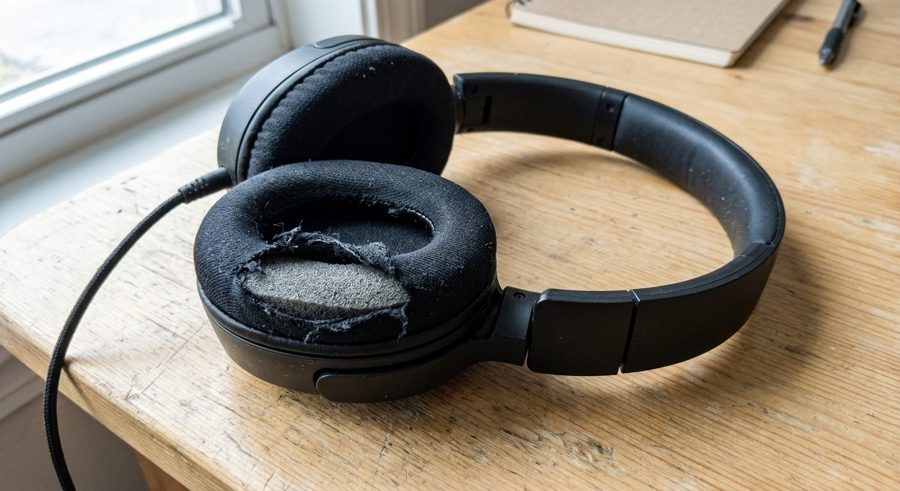

ticket-photo-headphones.jpg — 78 KB


In [35]:
import base64

from IPython.display import Image, display

PHOTO = Path.cwd().parent / "data" / "images" / "ticket-photo-headphones.jpg"

display(Image(filename=str(PHOTO), width=440))
print(f"{PHOTO.name} — {PHOTO.stat().st_size / 1024:.0f} KB")

In [36]:
photo_b64 = base64.b64encode(PHOTO.read_bytes()).decode("utf-8")

interaction = client.interactions.create(
    model=MODEL,
    input=[
        {"type": "text", "text": (
            "A customer attached this photo to a warranty claim for ShopWise.\n"
            "1. What product is it?\n"
            "2. What specifically is damaged?\n"
            "3. Does this look like manufacturing failure or normal wear?\n"
            "Answer in three short lines. Say plainly if you cannot tell."
        )},
        {"type": "image", "data": photo_b64, "mime_type": "image/jpeg"},
    ],
)

print(interaction.output_text.strip())

1. The product is a pair of wired over-ear headphones.
2. The fabric covering on the ear cushion is torn, exposing the foam padding.
3. This is consistent with normal wear and tear from friction and extended use.


Sit with that for a second: nobody wrote image-processing code. The same three-line call that triaged
text read a photograph and reasoned about wear versus manufacturing failure.

**And now the professional caution**, because this capability is the easiest one to over-trust. The
model is describing what the picture *looks like*. It cannot know how old the product is, whether the
customer sat on it, or what ShopWise's warranty actually covers. Question 3 is genuinely beyond a
photograph — watch whether it hedged appropriately or answered confidently anyway. Either way, the
architecture lesson is the same one that runs through this whole course: **a model's opinion is an
input to a decision, never the decision itself.** Session 11 is where a human signs off before money
moves.

### 4.4 Answering from the live web — search grounding with citations

💳 **Instructor demo — needs a billing-enabled key.**

A model's knowledge is frozen at whenever its training data stopped. Ask it about this morning's
news, or a competitor's current price, and it has nothing — but it will often answer anyway, because
producing a plausible continuation is what it does.

Giving it a **search tool** changes that. Watch two things in the output: the answer is current, and
every claim carries a URL you can click and check. That second part is what makes this usable in a
business setting, and it previews session 9, where we make ShopWise cite its own policy documents or
refuse to answer.

This is also the foundation of the course's [ADV] "Market Analyst" track from session 12.

In [37]:
try:
    interaction = client.interactions.create(
        model=MODEL,
        input=(
            "ShopWise sells consumer electronics online. What return window do the major "
            "online electronics retailers currently advertise? Answer in three bullets, "
            "and name the retailer for each."
        ),
        tools=[{"type": "google_search"}],
    )

    print(interaction.output_text.strip())

    # The step timeline now contains search steps — the model decided to use the
    # tool, read the results, and only then answered.
    print(f"\nsteps taken: {[s.type for s in interaction.steps]}")

    # Citations arrive as annotations attached to the text blocks. The same source
    # is often cited for several sentences, so we de-duplicate before printing.
    sources = {}
    for step in interaction.steps:
        if step.type != "model_output":
            continue
        for block in step.content:
            for annotation in getattr(block, "annotations", None) or []:
                if annotation.type == "url_citation":
                    sources.setdefault(annotation.title, annotation.url)

    print(f"\nSources ({len(sources)}):")
    for title, url in sources.items():
        print(f"  · {title:22} {url[:58]}…")

except Exception as err:
    print("Search grounding did not run.")
    print(explain_error(err))

Major online electronics retailers maintain varying return policies, often contingent on the specific product category, membership status, and whether the item is sold directly by the retailer or a third-party seller.

Here are the return windows for three major electronics retailers:

*   **Best Buy:** Most products have a **15-day** return window, though "My Best Buy Plus" and "Total" members receive an extended **60-day** window. Certain items, such as activatable devices (e.g., cell phones), typically have a shorter **14-day** return period.
*   **Amazon:** For most electronics, the standard return window is **30 days** from the date of delivery. However, certain categories—such as specific high-tech electronics, cameras, or computers—may have a shorter **14-day** return window depending on the seller and specific product conditions.
*   **Newegg:** The company generally offers a **30-day** return window from the date of delivery for items sold and shipped directly by Newegg. Note 

Notice what appeared in `steps`. On our very first call the timeline was
`['thought', 'model_output']`. Give the model a tool and the timeline grows — it now searches, reads
the results, and *then* answers. Nobody wrote that loop. We handed over one tool and the model
sequenced the work itself.

That is an **agent**, in one argument, and it is what session 5 takes apart and rebuilds by hand so
that it becomes a tool you understand rather than a trap you rely on.

Two practical notes about the citations, because both surprise people:

- **The URLs are Google redirect links**, not the publisher's address. They resolve to the real page
  when opened; Google routes them so it can attribute the traffic. If you are building a UI, show
  the `title` and let the redirect do its job.
- **The same source is cited repeatedly** — once per sentence it supported — which is why the cell
  de-duplicates before printing. A citation list that repeats "bestbuy.com" six times looks broken
  to a customer even though it is technically correct.

### 4.5 Making an image — the replacement product listing

💳 **Instructor demo — needs a billing-enabled key.**

Generation is not only text. ShopWise needs listing photography, seasonal banners and social posts,
and a shop owner in Mirpur does not have a photo studio. A different model — the same client, the
same `create` call — returns an image instead of words.

The only real difference is that the result arrives as base64 bytes on `output_image` rather than
text on `output_text`.

image/jpeg — 1408x768


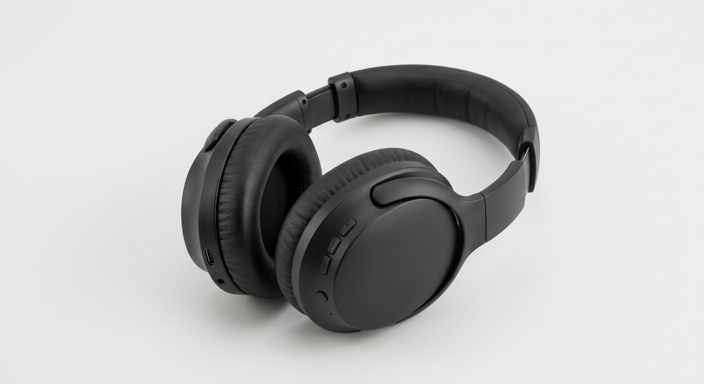

In [38]:
from io import BytesIO

from PIL import Image as PILImage

try:
    interaction = client.interactions.create(
        model=MODEL_IMAGE,
        input=(
            "A clean e-commerce product photo for an online electronics store: "
            "matte black over-ear headphones on a plain light background, "
            "soft studio lighting, slight angle, no text, no logos, no branding."
        ),
    )

    generated = PILImage.open(BytesIO(base64.b64decode(interaction.output_image.data)))
    print(f"{interaction.output_image.mime_type} — {generated.size[0]}x{generated.size[1]}")
    display(generated.resize((generated.width // 2, generated.height // 2)))

except Exception as err:
    print("Image generation did not run.")
    print(explain_error(err))

Two things worth saying out loud about generated images, and neither is technical:

- **Disclose it.** An invented product photo used as if it were the real item is a
  misrepresentation, whatever the tooling. Generated *concept* imagery, banners and mockups are
  ordinary commercial work; a generated photo of the thing in the box is not.
- **This is where costs stop being trivial.** A text triage is a fraction of a paisa. Images are
  priced per image and are orders of magnitude more. section 5 is about learning to look before you scale
  anything up.

### 4.6 Streaming — why every chat interface feels fast

When you use ChatGPT or Gemini, words appear as they are produced rather than after the whole answer
is finished. That is not a UI animation; it is the API handing back pieces as the model generates
them.

The total time is identical. The *perceived* time is transformed, because the reader starts reading
immediately. Session 6 wires this into ShopWise, and session 15 puts it on screen in React.

`stream=True` changes the return value from an object into something you loop over.

In [56]:
stream = client.interactions.create(
    model=MODEL,
    input=(
        "Write a warm three-sentence apology to a ShopWise customer whose order is "
        "five days late. Do not promise a specific new delivery date."
    ),
    stream=True,
)

for event in stream:
    delta = getattr(event, "delta", None)
    # The stream carries several kinds of event — the model's internal thinking,
    # step boundaries, status updates. We want only the text pieces.
    if delta is not None and getattr(delta, "type", None) == "text":
        print(delta.text, end="", flush=True)

print()

We sincerely apologize for the delay in getting your ShopWise order to you, as we know how much you are looking forward to receiving it. Your package is currently in transit, and our team is working hard to ensure it reaches your doorstep as soon as possible. We truly appreciate your patience and thank you for being a valued member of the ShopWise community.


The `getattr` dance in that loop is not ceremony. A stream carries several kinds of event —
`step.start`, the model's internal thinking, status updates, `step.stop` — and only some of them are
text you want to show a customer. Filtering to the pieces you actually want is the entire job of a
streaming handler, and it is why session 6 spends real time here.

Also note what streaming does *not* do: it is not faster, and you cannot validate a JSON schema
against half an answer. Streaming and structured output pull in opposite directions — a genuine
design trade-off you will make in session 13.

### 4.7 Remembering the conversation

A model has no memory between calls. Ask it a follow-up question with a fresh request and it has no
idea what you are talking about — which is why "the AI forgot what I said" is the most common
complaint about home-made chatbots.

There are exactly two ways to fix that, and you should know both:

1. **Resend everything.** Keep the transcript yourself and send the whole history with every request.
   Total control, and you pay for the whole conversation on every single turn.
2. **Let the API keep it.** Pass the previous interaction's `id`, and the service links them.

The Interactions API supports both. Below is the second, because it is one argument. Session 6 builds
the first by hand, and session 11 makes it survive a server restart.

In [40]:
first = client.interactions.create(
    model=MODEL,
    input="I'm chasing order ORD-5002 — two kettles, ordered on the 1st, still not shipped.",
)
print("turn 1:", first.output_text.strip()[:220], "…\n")

second = client.interactions.create(
    model=MODEL,
    input="Which order number was that again, and what did I buy?",
    previous_interaction_id=first.id,     # <- the entire memory mechanism
)
print("turn 2:", second.output_text.strip())

turn 1: I can certainly help you look into that, but as an AI, **I do not have direct access to your company’s internal order management system or private databases.**

To get this resolved, please take one of the following step …



turn 2: You mentioned that the order number is **ORD-5002** and the items are **two kettles**. 

As a reminder, I don't have access to your personal records or company systems, so I am only repeating the details you provided in your first message!


It remembered. Now look at the cost of remembering:

In [41]:
print(f"turn 1 input tokens: {first.usage.total_input_tokens}")
print(f"turn 2 input tokens: {second.usage.total_input_tokens}")
print()
print("Turn 2's question is six words. The input token count is much larger than six words,")
print("because the earlier turn was sent to the model again underneath.")

turn 1 input tokens: 28
turn 2 input tokens: 307

Turn 2's question is six words. The input token count is much larger than six words,
because the earlier turn was sent to the model again underneath.


**This is the single most expensive misunderstanding in LLM applications.** A conversation is not
stored in the model. Every turn, the whole history goes back through it. A chat that runs for forty
turns is paying for turn 1 forty times over.

Nothing about `previous_interaction_id` avoids that — it saves you the bookkeeping, not the tokens.
Session 6 is where we start managing this deliberately: summarising old turns, dropping what no
longer matters, and deciding what is worth carrying forward.

## 5. What did that cost? Tokens, the unit of everything

You have now made a dozen calls. Time to understand the meter.

A model does not read characters or words. It reads **tokens** — chunks of text produced by a
tokenizer, roughly a common word or a fragment of a longer one. Everything is measured in them:

- **Cost** is per token, in both directions. You pay for what you send *and* what comes back.
- **The context window** — the maximum a model can consider at once — is measured in tokens.
- **Speed** is roughly proportional to tokens generated.

So "how many tokens is this?" is the question underneath every practical decision you will make about
an LLM application. Let's measure rather than guess.

### 5.1 Predict first

Below are three texts of almost exactly the same length in characters: an English ticket, a Bangla
ticket, and a few lines of Python.

**Before you run the cell, write down which one you think costs the most tokens per character.**
Genuinely write it down — the point of this exercise is destroyed if you read the answer first.

In [42]:
samples = {
    "English": "Where is my order? I ordered the AeroSound Pro headphones last week and it has not moved.",
    "Bangla":  "আমার অর্ডার কোথায়? আমি গত সপ্তাহে হেডফোন অর্ডার করেছি কিন্তু এখনো কিছু আসেনি বলে জানাচ্ছি।",
    "Python":  "def triage(text: str) -> dict:\n    return {'category': 'order_status', 'urgency': 3}",
}

print(f"{'text':10} {'tokens':>7} {'chars':>7} {'chars/token':>12}")
print("-" * 39)
for label, text in samples.items():
    n = client.models.count_tokens(model=MODEL, contents=text).total_tokens
    print(f"{label:10} {n:>7} {len(text):>7} {len(text) / n:>12.2f}")

text        tokens   chars  chars/token
---------------------------------------


English         21      89         4.24


Bangla          20      91         4.55


Python          29      84         2.90


**Most people guess Bangla, and most people are wrong.**

Bangla and English come out close to each other. **Code is the expensive one** — identifiers,
indentation, brackets and punctuation each fragment into their own tokens, so the same number of
characters costs far more.

The belief that non-Latin scripts cost several times more is not superstition; it was *emphatically
true* on GPT-2-era tokenizers, and the blog posts written then still rank first in search results
today. Modern tokenizers handle Bangla well. The measurement changed; the folklore didn't.

**The lesson that outlives these numbers:** you just contradicted a widely repeated claim in four
lines of code. Do that, rather than trusting an article older than the model you are using. Exercise
⭐ in `exercises.ipynb` makes you do it again on your own text.

### 5.2 Reading the meter on a real call

`count_tokens` is for planning *before* you send anything. For what a call actually consumed, read
`usage` on the response — and get into the habit of reading it, because it is the number that turns
into a bill.

Watch `total_thought_tokens` in particular. Modern models can do internal reasoning before they
answer, and **you pay for those tokens even though you never see them.** On `gemini-3.1-flash-lite`
it will usually read `0`, because a lite model does little or no thinking by default — that is a
large part of why it is cheap. Run the same cell against `gemini-2.5-pro` on a hard question and the
thinking count can exceed the visible answer several times over. A cost estimate built from the
words on screen would be wrong by that entire multiple.

In [43]:
interaction = client.interactions.create(
    model=MODEL,
    input=f"In one sentence, what does this customer want?\n\n{ticket['body']}",
)

u = interaction.usage
print(interaction.output_text.strip())
print()
print(f"input tokens    : {u.total_input_tokens}")
print(f"output tokens   : {u.total_output_tokens}")
print(f"thinking tokens : {u.total_thought_tokens}")
print(f"total           : {u.total_tokens}")
print()

# ShopWise handles roughly 200 tickets a day. What does triage alone cost, in tokens?
per_day = u.total_tokens * 200
print(f"200 tickets/day  ≈ {per_day:,} tokens/day")
print(f"                 ≈ {per_day * 30:,} tokens/month")

The customer is demanding that you either ship their two kettles (order ORD-5002) immediately or issue a refund due to long-standing delays and a lack of communication.

input tokens    : 73
output tokens   : 38
thinking tokens : 0
total           : 111

200 tickets/day  ≈ 22,200 tokens/day
                 ≈ 666,000 tokens/month


**Notice what this notebook refuses to tell you: a price.** Rates change, tiers change, and any
number printed here would be wrong within a term. What you are learning is the *habit* — read
`usage` on every response, multiply by whatever today's published rate is, and know the number before
you scale anything to production. From session 4, LangSmith records this automatically for every
call you make for the rest of the course.

And before you scale that monthly figure in your head: most of the cost in a real assistant is not
triage. It is the conversation history from section 4.7 and the retrieved documents from session 8, both of
which multiply the *input* side. Which is exactly why we measure.

### 5.3 Two things about the free tier, before you paste anything into a notebook

**Your free-tier prompts are used to train Google's models.** The pricing page lists "content used to
improve our products" as **Yes** for the free tier and **No** for paid. So never paste real customer
data, real names, card numbers, or anything belonging to an employer into a free-tier notebook. Every
ticket in `data/tickets.yml` is invented precisely so that this course needs nothing real. This is
not a formality — it is the first thing anyone will ask you about in a job interview on this topic.

**Rate limits are no longer published.** Google removed the requests-per-minute table from the docs;
it now says limits "can be viewed in Google AI Studio". So distrust any number in any blog post —
including any number in this notebook. Check your own:

- the docs page: https://ai.google.dev/gemini-api/docs/rate-limits
- your own dashboard: https://aistudio.google.com/rate-limit

We walk through both in class. If a cell starts returning `429 RESOURCE_EXHAUSTED`, that is a rate
limit and not a bug in your code: wait a minute and re-run.

## 6. The wider world: models, providers, and how to choose

Everything above used one model from one company. That was a teaching decision, not a
recommendation. This section is the map of the field, so you can hold an informed conversation about
it — in a design review, or an interview.

### 6.1 How we got here, briefly

The whole field runs on one architecture published in 2017. Everything since is scale, data and
tuning on top of it.

| | What happened | Why it still matters |
|---|---|---|
| **2017** | *Attention Is All You Need* — Google publishes the Transformer | everything since is built on this one architecture |
| **2018–2020** | GPT-1 → GPT-3 | the only change that mattered was **scale**: 175 billion parameters |
| **Nov 2022** | ChatGPT | the model was not new — the **chat box** was |
| **2023** | GPT-4 · LLaMA | multimodal input arrives; Meta releases weights, and the closed/open split begins |
| **2024–2026** | the current era | million-token context · reasoning models · agents · open weights closing on the frontier |


Two things in that timeline are worth more than the dates.

**ChatGPT was not a technical breakthrough.** The underlying model was already about two years old.
What changed in November 2022 was that someone put a *chat box* on it and made it free. The lesson
for you, as an applications engineer, is the one this entire course is built on: the value was in the
product wrapped around the model, not in the model.

**The pace is not slowing, and this is why we teach architecture rather than a model.** Every
capability you used in section 4 tonight — reading a photo, searching the live web, returning strict JSON —
was a research demo or unavailable at consumer scale three years ago. The specific model IDs in this
notebook will be retired. The *shape* of the application you are learning to build will not.

### 6.2 Who makes the models

One line matters more than any benchmark: **can you download the weights?**

| | **Closed weights** (API only) | **Open weights** (download and run) |
|---|---|---|
| Who | OpenAI (GPT) · Anthropic (Claude) · Google (Gemini) · xAI (Grok) | Meta (Llama) · Mistral · Alibaba (Qwen) · DeepSeek · Google (Gemma) |
| You get | an endpoint and a bill | files you can run on your own hardware |
| Best for | frontier capability, no ops burden | privacy, cost control, no lock-in, fine-tuning |
| Trade-off | your data leaves your building; models change under you | you own the GPUs, the latency and the uptime |

**"Open weights" is not "open source."** You get the trained parameters under a licence with
conditions — rarely the training data or the code that made them. Closer to a free binary.

It decides real cases before benchmarks are opened: a hospital or bank that cannot send customer data
to a US API has a *must run on our hardware* requirement, not a *which model scores higher* question.


### 6.3 Leaderboards — and how to read one

Every model launches with a chart showing it winning; self-reported benchmarks are marketing. The
useful independent signal is a blind community arena — **<https://arena.ai/leaderboard>** — where two
anonymous models answer, you pick the better, and millions of blind votes become an Elo rating.

Three caveats:

1. **It measures human preference, not correctness.** A confident, well-formatted, slightly wrong
   answer beats a hedged correct one.
2. **First place is usually noise.** The top several sit inside each other's error bars. "Top five"
   is signal; "#1 this week" is not.
3. **Use the category boards.** Coding, maths, long context and vision disagree with each other, and
   overall rank is nearly useless for a specific job.

**artificialanalysis.ai** plots quality against price and speed, which is the better decision aid:
the real question is never "which is best" but "which is good enough for the least money".


### 6.4 Hugging Face — the field's public library

**<https://huggingface.co>** — if a model has open weights, it is almost certainly there. Over two
million models as of 2026.

- **Models** — weights plus a card naming the training, licence and limitations. Read the licence
  before building a business on one.
- **Datasets** — public training and evaluation data; where you would publish a Bangla dataset.
- **Spaces** — hosted demos, the fastest way to try a model before installing anything.
- **`transformers`** — the library that runs most of them locally.

You will not download weights in this course — ShopWise runs on an API — but the ⭐⭐⭐ exercise sends
you there to look around.


### 6.5 Inference providers — the other half of the market

Downloading Llama is not the same as wanting to operate it: GPUs, batching, autoscaling, someone
awake at 3am. So an industry exists to run open models *for* you, behind an OpenAI-shaped API.

| Provider | Known for |
|---|---|
| **Groq** | custom hardware; open models at remarkable speed |
| **Together AI** | broad catalogue, plus fine-tuning |
| **Fireworks / Replicate** | fast hosted inference, image and video too |
| **OpenRouter** | one key in front of **hundreds** of models, closed and open, with live prices |

OpenRouter is a router, not a model maker: change a string, talk to another company's model, prices
visible per token.

**Why this matters to what we're building:** the model is a *replaceable component*. Session 4
introduces LangChain so that swapping Gemini for Claude, or for a Llama at Groq, is one line rather
than a rewrite. You are not learning Gemini; you are learning to build systems with a model in them.


### 6.6 What this course uses, and why

| Decision | Choice | Reason |
|---|---|---|
| Provider | Google Gemini | a genuinely useful free tier — nobody needs a card to attend |
| Default model | `gemini-3.1-flash-lite` | cheapest and fast; good enough for almost everything here |
| Stronger model | `gemini-3.6-flash` | when quality matters more than cost |
| Reasoning model | `gemini-2.5-pro` | hard problems, slower and dearer |
| Embeddings | `gemini-embedding-2` | session 8's retrieval |

**The listing below shows newer models than that table** — `gemini-3.7-flash` exists as you read
this. Deliberate, and the same call you will make at work:

- **Newer is not automatically better *for a given task*.** Paying more per token for a job the cheap
  model already passes is a cost, not an upgrade.
- **A course needs stable ground.** Every committed output was executed against these IDs.
- **Try the newer ones anyway.** Change `MODEL` in the setup cell, re-run section 4, and see whether
  anything you care about improves. That experiment *is* the skill.

Model IDs also get retired, so rather than trust any table, ask the API what exists today:


In [45]:
available = sorted(m.name.removeprefix("models/") for m in client.models.list())

print(f"{len(available)} models visible to this key\n")
for name in available:
    if name.startswith("gemini-3"):
        print(" ", name)

print("\n… plus embedding, image, video, audio and open Gemma models.")
print("If a model ID in this notebook 404s in a future term, this cell is where you find its replacement.")

50 models visible to this key

  gemini-3-flash-preview
  gemini-3-pro-image
  gemini-3-pro-image-preview
  gemini-3.1-flash-image
  gemini-3.1-flash-image-preview
  gemini-3.1-flash-lite
  gemini-3.1-flash-lite-image
  gemini-3.1-flash-lite-preview
  gemini-3.1-flash-live-preview
  gemini-3.1-flash-tts-preview
  gemini-3.1-pro-preview
  gemini-3.1-pro-preview-customtools
  gemini-3.5-flash
  gemini-3.5-flash-lite
  gemini-3.5-live-translate-preview
  gemini-3.6-flash
  gemini-3.7-flash

… plus embedding, image, video, audio and open Gemma models.
If a model ID in this notebook 404s in a future term, this cell is where you find its replacement.


## 7. What you now know, and what happens next

| Before today | After today |
|---|---|
| "AI" as one undifferentiated thing | AI ⊃ ML ⊃ deep learning ⊃ generative AI ⊃ LLMs, and why we work in the last one |
| An LLM writes text | it reads photos, searches the live web with sources, returns validated JSON, and streams |
| Python "which I sort of know" | a 22-part reference that names the session each part is needed in |
| Cost is per request | cost is per token, both directions, thinking included — and code costs more than prose |
| One model, one company | closed vs open weights, arena leaderboards, Hugging Face, inference providers |
| No environment | `uv`, `.env`, checker green |

### Exercises — before Saturday

`exercises.ipynb`, three of them, tagged ⭐ / ⭐⭐ / ⭐⭐⭐. Do them before session 2 — the ⭐⭐ one is
the scaffold session 2 builds on.

### Next session — Talking to the machines

You stop watching a demo and start writing the calls. Your own key, your own requests, and the three
roles — **system, user, assistant** — that every chat application on earth is built from. ShopWise
**v0.1** gets committed to your repo.

And you meet the problem that shapes the next eight sessions. Tonight the model looked capable.
Tomorrow we ask it about ShopWise's actual return policy, and it will answer — fluently, warmly,
with total confidence, and completely invented. It has never heard of ShopWise. Nothing in the
machinery distinguishes a fact it was told from a plausible sentence.

*"It has a brain, no hands, and no memory. Tomorrow we start fixing that."*